In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from utils.model_fitting import *
from utils.plots import *
from utils.path import PathConfig, FigureWithData
from rl.models import Tonic_DA_model

warnings.filterwarnings("ignore")
rseed =10
np.random.seed(rseed)

fig_dir = os.path.join('figures', 'figure_2')
data_fig_dir = os.path.join('data', 'source_data', 'figure_2')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)


## Tonic Dopamine model

This notebook performs the basic predictions of the tonic Dopamine model proposed in the manuscript:  *Romero Pinto, S., & Uchida, N. (2023). **Tonic dopamine and biases in value learning linked through a biologically inspired reinforcement learning model***

**Note:** No data is needed for this notebook


In [2]:
md = Tonic_DA_model()
DA = md.DA
ec50_1 = md.ec50_1
ec50_2 = md.ec50_2
delta_DA = md.delta_DA
slope_D1_log, slope_D2_log = md.compute_sensitivities(type_scale='log')
taus_log = md.compute_taus(type_scale='log')
slope_D1_lin, slope_D2_lin = md.compute_sensitivities(type_scale='lin')
taus_lin = md.compute_taus(type_scale='lin')
occ_D1, occ_D2, DA_occ =md.compute_dose_occupancy(DA_range = [-2,6])
colorD1 = 'deepskyblue'
colorD2 = 'hotpink'

### Figure 2c
Dose-occupancy curves for the D1R and D2R describing receptor occupancies as a function of dopamine concentrations

Saved figure to figures/figure_2/figure_2c.pdf
Saved data and stats to data/figure_data/figure_2/figure_2c.txt


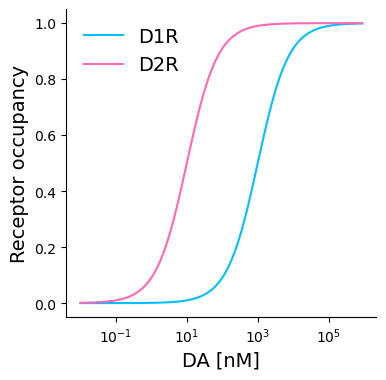

In [3]:
fig, ax = plt.subplots(figsize = (4,4))
ax.semilogx(DA_occ,occ_D1,color=colorD1,linewidth=1.5,label='D1R')
ax.semilogx(DA_occ,occ_D2,color=colorD2,linewidth=1.5,label='D2R')
plot_config(ax,'DA [nM]','Receptor occupancy',14,True)

# --- Prepare data to save ---
# 1. Create the wrapper
fig_data_2c = FigureWithData(fig)

# 2. Add Panel 0: DA vs Tau_D1R and Tau_D2R
panel0_data = np.column_stack((DA_occ, occ_D1, occ_D2))  # [n_points, 3 columns]
panel0_headers = ['DA_concentration_nM', 'Occupancy_D1R', 'Occupancy_D2R']

fig_data_2c.add_data(
    "Dose occupancy curve",
    panel0_data,
    panel0_headers
)

# 4. Save everything (figure + data)
fig_data_2c.save(
    base_filename='figure_2c',    # or any name you want
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)


